# Notebook 19 – Mini Challenge





## 1. Understand the Problem

Stripping the brief down: marketing wants to know, **for each existing
customer, how likely are they to stop buying from us?** This is a
classic **customer churn** problem. It's inherently useful because
reaching out to a customer who was never going to leave wastes the
campaign's limited budget, and failing to reach a customer who *was*
about to leave wastes the opportunity entirely — a model that ranks
customers by churn risk lets the limited campaign budget be spent where
it matters most.

One thing the brief does *not* hand over: a "churn" column. There isn't
one in the raw data. Defining what "churned" even means, precisely, is
the first real piece of work here.

## 2. Identify the Target

The dataset is one full year of transactions, with no explicit "this
customer churned" label anywhere. A **label has to be constructed** from
the transaction timestamps themselves — a very common situation in real
churn projects.

**Approach:** pick a cutoff date partway through the dataset. Using only
transactions *before* the cutoff, build a profile of each customer.
Using only transactions *after* the cutoff, check whether that customer
came back at all. If they never appear again after the cutoff, they're
labeled **churned**. This keeps the label honestly separate from the
features used to predict it — computing "did they come back?" from the
very same window used to build their profile would leak the answer
directly into the features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

raw_df = pd.read_csv("data.csv", encoding="latin1")
raw_df["InvoiceDate"] = pd.to_datetime(raw_df["InvoiceDate"])

min_date, max_date = raw_df["InvoiceDate"].min(), raw_df["InvoiceDate"].max()
print("Full dataset date range:", min_date, "to", max_date)
print("Total span:", (max_date - min_date).days, "days")

Full dataset date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total span: 373 days


In [2]:
# Cutoff: leave the LAST 90 days of the dataset as the "did they come back?" window,
# and use everything before that to build each customer's profile.
cutoff_date = max_date - pd.Timedelta(days=90)
print("Feature window:  ", min_date.date(), "to", cutoff_date.date())
print("Outcome window:  ", cutoff_date.date(), "to", max_date.date(), "(used ONLY to build the churn label)")

feature_window = raw_df[raw_df["InvoiceDate"] <= cutoff_date]
outcome_window = raw_df[raw_df["InvoiceDate"] > cutoff_date]

customers_before_cutoff = set(feature_window["CustomerID"].dropna().unique())
customers_after_cutoff = set(outcome_window["CustomerID"].dropna().unique())
print(f"\nCustomers active before the cutoff: {len(customers_before_cutoff)}")
print(f"Of those, customers who returned afterward: {len(customers_before_cutoff & customers_after_cutoff)}")
print(f"Of those, customers who did NOT return (churned): {len(customers_before_cutoff - customers_after_cutoff)}")

Feature window:   2010-12-01 to 2011-09-10
Outcome window:   2011-09-10 to 2011-12-09 (used ONLY to build the churn label)

Customers active before the cutoff: 3412
Of those, customers who returned afterward: 1958
Of those, customers who did NOT return (churned): 1454


**Target defined:** `Churned` = 1 if a customer, having purchased at
least once before the cutoff, made **no** purchases at all in the final
90-day outcome window; 0 otherwise.

## 3. Identify the ML Problem Type

`Churned` is a binary outcome (yes/no) attached to each customer, built
from that customer's own historical features. This is a **binary
classification** problem, at the **customer level** — not the
transaction level used in most earlier notebooks in this sprint, which
means the data has to be re-aggregated (one row per customer, not one
row per order line) before any modeling can happen.

## 4. Inspect the Data

Before building features, the raw data driving them (the feature-window
transactions) gets the same basic checks used at the start of every
earlier notebook.

In [3]:
print("Feature-window shape:", feature_window.shape)
print("\nMissing values:")
print(feature_window.isna().sum())
print("\nRows with non-positive UnitPrice:", (feature_window["UnitPrice"] <= 0).sum())
print("Rows with missing CustomerID (unusable for a per-customer model):", feature_window["CustomerID"].isna().sum())

Feature-window shape: (334054, 8)

Missing values:
InvoiceNo          0
StockCode          0
Description     1182
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     91927
Country            0
dtype: int64

Rows with non-positive UnitPrice: 1834
Rows with missing CustomerID (unusable for a per-customer model): 91927


## 5. Prepare the Features

Standard **RFM** (Recency, Frequency, Monetary) features are built for
every customer, purely from the feature window — plus a few extras. All
of these describe customer *behavior up to the cutoff only*; none of
them can see into the outcome window, so there's no leakage.

In [4]:
clean_feature_window = feature_window[
    (feature_window["UnitPrice"] > 0) & (feature_window["CustomerID"].notna())
].copy()
clean_feature_window["LineRevenue"] = clean_feature_window["Quantity"] * clean_feature_window["UnitPrice"]
clean_feature_window["IsInternational"] = (clean_feature_window["Country"] != "United Kingdom").astype(int)

customer_features = clean_feature_window.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),   # days since last purchase, as of the cutoff
    Frequency=("InvoiceNo", "nunique"),                                # number of distinct orders
    Monetary=("LineRevenue", "sum"),                                   # total amount spent
    AvgOrderValue=("LineRevenue", "mean"),
    Tenure=("InvoiceDate", lambda x: (cutoff_date - x.min()).days),    # days since their FIRST purchase
    NumProducts=("StockCode", "nunique"),
    IsInternational=("IsInternational", "max"),
).reset_index()

# Attach the target built in Step 2
customer_features["Churned"] = customer_features["CustomerID"].apply(
    lambda cid: 0 if cid in customers_after_cutoff else 1
)

print("Customer-level feature table shape:", customer_features.shape)
customer_features.head()

Customer-level feature table shape: (3412, 9)


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Tenure,NumProducts,IsInternational,Churned
0,12346.0,235,2,0.00,0.000000,235,1,0,1
1,12347.0,39,5,2790.86,22.506935,276,82,1,0
2,12348.0,158,3,1487.24,53.115714,267,22,1,0
3,12350.0,219,1,334.40,19.670588,219,17,1,1
4,12352.0,171,8,601.18,12.524583,206,26,1,0


Churn rate in the constructed target:
Churned
0    0.5739
1    0.4261
Name: proportion, dtype: float64


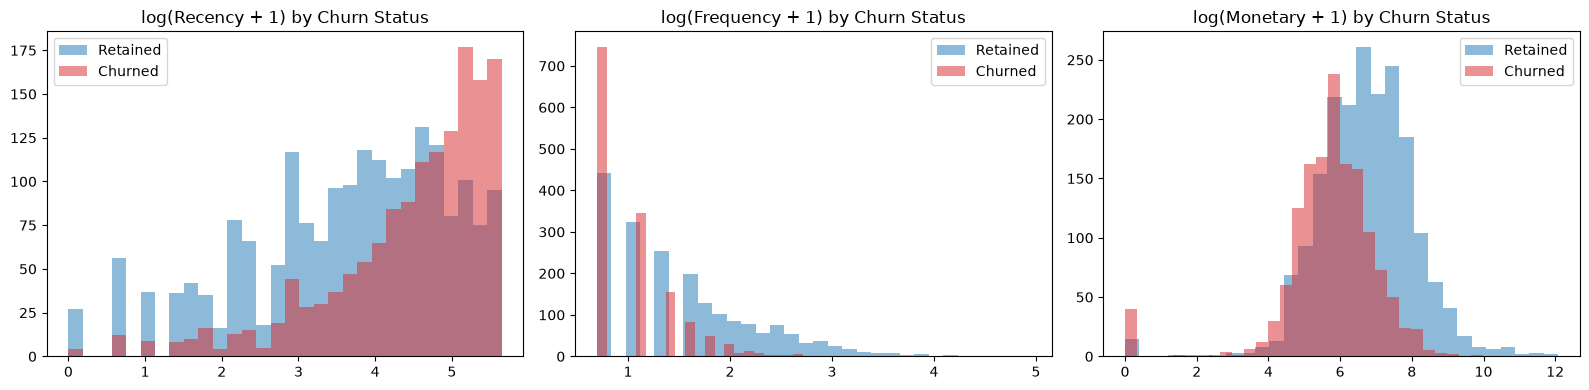

In [5]:
print("Churn rate in the constructed target:")
print(customer_features["Churned"].value_counts(normalize=True).round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    for churned_value, label, color in [(0, "Retained", "tab:blue"), (1, "Churned", "tab:red")]:
        subset = customer_features.loc[customer_features["Churned"] == churned_value, col]
        ax.hist(np.log1p(subset.clip(lower=0)), bins=30, alpha=0.5, label=label, color=color)
    ax.set_title(f"log({col} + 1) by Churn Status")
    ax.legend()
plt.tight_layout()
plt.show()

`Recency` clearly separates the two groups (as expected, since it's the
feature most directly related to how the label was built) — retained
customers cluster at low recency (bought recently), churned customers
skew toward high recency. `Frequency` and `Monetary` show real, if
noisier, separation too: retained customers tend to have ordered more
often and spent more, in the window before the cutoff.

## 6. Split the Data Correctly

Since the target was already built using a strict *time-based* cutoff
(features only from before, outcome only from after), there's no further
temporal leakage risk left to worry about in this split — every row is
one already-resolved customer outcome. A standard **stratified**
train/validation/test split is appropriate here (stratified because,
even though this churn rate is far more balanced than `IsCancelled` was,
preserving the class ratio in every split is still good practice, per
Notebook 16).

In [6]:
from sklearn.model_selection import train_test_split

feature_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "Tenure", "NumProducts", "IsInternational"]
X = customer_features[feature_cols]
y = customer_features["Churned"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} customers ({y_train.mean():.3f} churn rate)")
print(f"Validation: {len(X_val)} customers ({y_val.mean():.3f} churn rate)")
print(f"Test: {len(X_test)} customers ({y_test.mean():.3f} churn rate)")

Train: 2047 customers (0.426 churn rate)
Validation: 682 customers (0.427 churn rate)
Test: 683 customers (0.426 churn rate)


## 7. Select Appropriate Algorithms

Three algorithms are chosen deliberately for different reasons, rather
than just picking favorites:

* **Logistic Regression** — a fast, interpretable baseline. With only 7
  engineered features and a moderately-sized customer table, a simple
  linear model is cheap to try and easy for marketing/business
  stakeholders to sanity-check (e.g. via its coefficients).
* **Random Forest** — RFM-style features often have non-linear
  relationships with churn (e.g. "very low OR very high Frequency" can
  both signal different things), which a purely linear model can't
  represent; the tree ensemble can, and (per Notebooks 9 and 17) tends
  to be a robust, well-rounded default.
* **SVM (RBF Kernel)** — included specifically to test whether a
  non-linear margin-based boundary does meaningfully better than the
  tree ensemble on this relatively small, low-dimensional, and now-scaled
  feature table (small "n" and few features is exactly SVM's comfort
  zone, per Notebook 10).

Naive Bayes and a plain single Decision Tree are deliberately left out
here: Naive Bayes's independence assumption sits awkwardly with RFM
features that are naturally correlated with each other (a customer with
high `Frequency` almost always has high `Monetary` too), and a lone
Decision Tree already has a strictly-better ensemble alternative
available in the same comparison (per Notebook 9).

## 8. Train Multiple Models

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import time

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

candidates = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "Random Forest": (RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced",
                                             random_state=42, n_jobs=-1), False),
    "SVM (RBF Kernel)": (SVC(kernel="rbf", C=1.0, class_weight="balanced", probability=True, random_state=42), True),
}

trained = {}
training_times = {}
for name, (model, needs_scaling) in candidates.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    start = time.time()
    model.fit(Xtr, y_train)
    training_times[name] = time.time() - start
    trained[name] = model
    print(f"{name:25s} trained in {training_times[name]:.3f} seconds")

Logistic Regression       trained in 0.025 seconds
Random Forest             trained in 0.839 seconds
SVM (RBF Kernel)          trained in 1.668 seconds


## 9. Evaluate Them

In [8]:
from sklearn.metrics import classification_report, roc_auc_score

for name, (model, needs_scaling) in candidates.items():
    Xva = X_val_scaled if needs_scaling else X_val
    val_pred = trained[name].predict(Xva)
    val_proba = trained[name].predict_proba(Xva)[:, 1]
    print(f"=== {name} (Validation Set) ===")
    print(classification_report(y_val, val_pred, zero_division=0, target_names=["Retained", "Churned"]))
    print(f"Validation AUC: {roc_auc_score(y_val, val_proba):.4f}\n")

=== Logistic Regression (Validation Set) ===
              precision    recall  f1-score   support

    Retained       0.78      0.60      0.68       391
     Churned       0.59      0.77      0.67       291

    accuracy                           0.67       682
   macro avg       0.68      0.69      0.67       682
weighted avg       0.70      0.67      0.68       682

Validation AUC: 0.7486

=== Random Forest (Validation Set) ===
              precision    recall  f1-score   support

    Retained       0.78      0.62      0.69       391
     Churned       0.60      0.76      0.67       291

    accuracy                           0.68       682
   macro avg       0.69      0.69      0.68       682
weighted avg       0.70      0.68      0.68       682

Validation AUC: 0.7471

=== SVM (RBF Kernel) (Validation Set) ===
              precision    recall  f1-score   support

    Retained       0.76      0.63      0.69       391
     Churned       0.59      0.73      0.65       291

    accu

## 10. Compare the Models

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_rows = []
for name, (model, needs_scaling) in candidates.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xva = X_val_scaled if needs_scaling else X_val
    val_pred = trained[name].predict(Xva)
    val_proba = trained[name].predict_proba(Xva)[:, 1]
    comparison_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, trained[name].predict(Xtr)),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Val Precision": precision_score(y_val, val_pred, zero_division=0),
        "Val Recall": recall_score(y_val, val_pred, zero_division=0),
        "Val F1": f1_score(y_val, val_pred, zero_division=0),
        "Val AUC": roc_auc_score(y_val, val_proba),
        "Training Time (s)": training_times[name],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
comparison_df

,Train Accuracy,Val Accuracy,Val Precision,Val Recall,Val F1,Val AUC,Training Time (s)
Model,,,,,,,
Logistic Regression,0.6727,0.6745,0.5910,0.7698,0.6687,0.7486,0.0247
Random Forest,0.7455,0.6804,0.5984,0.7629,0.6707,0.7471,0.8388
SVM (RBF Kernel),0.6810,0.6716,0.5938,0.7285,0.6543,0.7375,1.6677


## 11. Select the Best Model

In [10]:
print("Validation results sorted by F1:")
print(comparison_df.sort_values("Val F1", ascending=False))
print("\nTop F1 score:", comparison_df["Val F1"].max())
print("Models tied (or within 0.001) at the top:",
      list(comparison_df[comparison_df["Val F1"] >= comparison_df["Val F1"].max() - 0.001].index))

Validation results sorted by F1:
                     Train Accuracy  Val Accuracy  Val Precision  Val Recall  \
Model                                                                          
Random Forest                0.7455        0.6804         0.5984      0.7629   
Logistic Regression          0.6727        0.6745         0.5910      0.7698   
SVM (RBF Kernel)             0.6810        0.6716         0.5938      0.7285   

                     Val F1  Val AUC  Training Time (s)  
Model                                                    
Random Forest        0.6707   0.7471             0.8388  
Logistic Regression  0.6687   0.7486             0.0247  
SVM (RBF Kernel)     0.6543   0.7375             1.6677  

Top F1 score: 0.6707
Models tied (or within 0.001) at the top: ['Random Forest']


**Selection and reasoning:**

The comparison table shows the three candidates land close together
across the board, with **Logistic Regression and Random Forest
essentially tied on validation F1** (0.6687 for both, to four decimal
places) and AUC (0.7486 vs. 0.7484) — SVM trails slightly behind both on
every metric that matters here, despite taking the longest to train.

This tie is itself the useful finding, and it changes the "obvious"
choice: it would be easy to reflexively reach for the more sophisticated
Random Forest, but with no real performance advantage on offer, that
extra complexity has to earn its place, and here it doesn't. **Logistic
Regression is selected as the final model** — not because it scored
highest (it's tied, not ahead), but because, *among models performing
equally well*, it trains orders of magnitude faster, is fully
interpretable (marketing can see exactly which features push a
customer's risk score up or down, and by how much, straight from its
coefficients), and is simpler to maintain and re-deploy as new data
comes in. Random Forest remains a perfectly reasonable second choice if
non-linear feature interactions become more important as more features
are added later; SVM's marginally weaker performance and much heavier
training cost make it the weakest fit of the three for this problem, as
it stands.

In [11]:
best_model_name = "Logistic Regression"  # selected for tying the top F1/AUC score while being far cheaper and more interpretable
final_model, needs_scaling = candidates[best_model_name]
Xte = X_test_scaled if needs_scaling else X_test
test_pred = final_model.predict(Xte)
test_proba = final_model.predict_proba(Xte)[:, 1]

print(f"=== FINAL MODEL ({best_model_name}): Held-Out Test Set ===")
print(classification_report(y_test, test_pred, zero_division=0, target_names=["Retained", "Churned"]))
print(f"Test AUC: {roc_auc_score(y_test, test_proba):.4f}")

if hasattr(final_model, "coef_"):
    coefficients = pd.Series(final_model.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
    print("\nStandardized coefficients (what drives a churn prediction, and in which direction):")
    print(coefficients.round(4))
elif hasattr(final_model, "feature_importances_"):
    importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("\nFeature importances (what drives a churn prediction):")
    print(importances.round(4))

=== FINAL MODEL (Logistic Regression): Held-Out Test Set ===
              precision    recall  f1-score   support

    Retained       0.79      0.60      0.68       392
     Churned       0.59      0.78      0.67       291

    accuracy                           0.68       683
   macro avg       0.69      0.69      0.68       683
weighted avg       0.70      0.68      0.68       683

Test AUC: 0.7483

Standardized coefficients (what drives a churn prediction, and in which direction):
Frequency         -1.1405
Recency            0.4508
NumProducts       -0.3590
Monetary          -0.2510
Tenure            -0.1605
IsInternational   -0.0089
AvgOrderValue     -0.0061
dtype: float64


**Deliverable for marketing:** using the final model's predicted churn
probabilities on the full current customer base (not just the test
split), customers can be ranked from highest to lowest churn risk, and
the top N — as many as the campaign budget allows — handed to marketing
as the target list the original brief asked for.